## Tf-Idf(Term Frequency- Inverse Document Frequency)

tf-idf  is a method used in nlp and info retrival to evaluate  how important  a word is to a document in relation to larger collection of documents.

term frequency measures how often a word appears  in a  document.
higher tf suggests greater importance.
If a term appears frequently in a document, it is likely relevant to the document’s content.

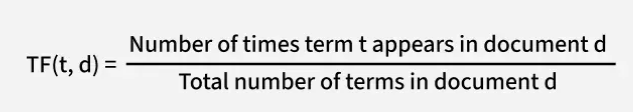

##### lets create a sample dataset and calculate the term frequency

In [2]:
import pandas as pd

# Create the dataframe with 'Document' as the index
df = pd.DataFrame(
    {
        'Text': [
            'people watch campusx',
            'campusx watch campusx',
            'people write comment',
            'campusx write comment'
        ]
    },
    index=['D1', 'D2', 'D3', 'D4']
)

df

,Text
D1,people watch campusx
D2,campusx watch campusx
D3,people write comment
D4,campusx write comment


### Term Frequency (TF) Calculation

#### D1 → "people watch campusx"

Total words in D1 = 3

TF(people, D1)   = 1 / 3  
TF(watch, D1)    = 1 / 3  
TF(campusx, D1)  = 1 / 3  


#### D2 → "campusx watch campusx"

Total words in D2 = 3

TF(campusx, D2)  = 2 / 3  
TF(watch, D2)    = 1 / 3  


#### D3 → "people write comment"

Total words in D3 = 3

TF(people, D3)   = 1 / 3  
TF(write, D3)    = 1 / 3  
TF(comment, D3)  = 1 / 3  


#### D4 → "campusx write comment"

Total words in D4 = 3

TF(campusx, D4)  = 1 / 3  
TF(write, D4)    = 1 / 3  
TF(comment, D4)  = 1 / 3  

## Inverse Document Frequency(IDF)

Idf measures how rare or unique a word is across all documents in the corpus. it reduces the weight of common words across multiple documents while increasing the weight of rare words. If a term appears in fewer documents, it is more likely to be meaningful and specific.

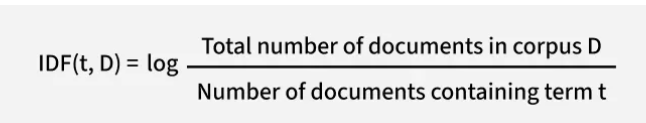

## now lets the idf

total numbeer of documents in corpuse D= D1,  D2, D3, D4 ie=4

we calculate IDF for each individual word (term) in the vocabulary.

### Inverse Document Frequency (IDF) Calculation

Total number of documents (N) = 4

IDF(people, D)   = log10(4 / 2) = log10(2)     ≈ 0.301  
IDF(watch, D)    = log10(4 / 2) = log10(2)     ≈ 0.301  
IDF(campusx, D)  = log10(4 / 3) = log10(1.33)  ≈ 0.125  
IDF(write, D)    = log10(4 / 2) = log10(2)     ≈ 0.301  
IDF(comment, D)  = log10(4 / 2) = log10(2)     ≈ 0.301  

### Final TF-IDF Calculation

TF-IDF = TF × IDF

#### D1 → "people watch campusx"

- TF-IDF(people, D1)   = 1/3 × 0.301  ≈ 0.100  
- TF-IDF(watch, D1)    = 1/3 × 0.301  ≈ 0.100  
- TF-IDF(campusx, D1)  = 1/3 × 0.125  ≈ 0.042  

Vector(D1) = [people: 0.100, watch: 0.100, campusx: 0.042, write: 0, comment: 0]  


#### D2 → "campusx watch campusx"

- TF-IDF(campusx, D2)  = 2/3 × 0.125  ≈ 0.083  
- TF-IDF(watch, D2)    = 1/3 × 0.301  ≈ 0.100  

Vector(D2) = [people: 0, watch: 0.100, campusx: 0.083, write: 0, comment: 0]  


#### D3 → "people write comment"

- TF-IDF(people, D3)   = 1/3 × 0.301  ≈ 0.100  
- TF-IDF(write, D3)    = 1/3 × 0.301  ≈ 0.100  
- TF-IDF(comment, D3)  = 1/3 × 0.301  ≈ 0.100  

Vector(D3) = [people: 0.100, watch: 0, campusx: 0, write: 0.100, comment: 0.100]  


#### D4 → "campusx write comment"

- TF-IDF(campusx, D4)  = 1/3 × 0.125  ≈ 0.042  
- TF-IDF(write, D4)    = 1/3 × 0.301  ≈ 0.100  
- TF-IDF(comment, D4)  = 1/3 × 0.301  ≈ 0.100  

Vector(D4) = [people: 0, watch: 0, campusx: 0.042, write: 0.100, comment: 0.100]  

## Code Demo

In [4]:
import pandas as pd

# Create the dataframe
df = pd.DataFrame(
    {
        'Text': [
            'people watch campusx',
            'campusx watch campusx',
            'people write comment',
            'campusx write comment'
        ]
    }
)

# Add output column
df['output'] = [1, 1, 0, 0]

df

,Text,output
0,people watch campusx,1
1,campusx watch campusx,1
2,people write comment,0
3,campusx write comment,0


In [5]:
from numpy import vectorize
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer()
tfidf_vectors=vectorizer.fit_transform(df['Text'])

In [7]:
tfidf_vectors.toarray()

array([[0.49681612, 0.        , 0.61366674, 0.61366674, 0.        ],
       [0.8508161 , 0.        , 0.        , 0.52546357, 0.        ],
       [0.        , 0.57735027, 0.57735027, 0.        , 0.57735027],
       [0.49681612, 0.61366674, 0.        , 0.        , 0.61366674]])

In [13]:
print(vectorizer.idf_)

[1.22314355 1.51082562 1.51082562 1.51082562 1.51082562]


In [14]:
print(vectorizer.get_feature_names_out())

['campusx' 'comment' 'people' 'watch' 'write']


#### convert TF-IDF matrix to dataFrame

In [15]:
tdif_df= pd.DataFrame(tfidf_vectors.toarray(),columns=vectorizer.get_feature_names_out())
tdif_df

,campusx,comment,people,watch,write
0,0.496816,0.000000,0.613667,0.613667,0.000000
1,0.850816,0.000000,0.000000,0.525464,0.000000
2,0.000000,0.577350,0.577350,0.000000,0.577350
3,0.496816,0.613667,0.000000,0.000000,0.613667


In [16]:
# Concatenate TF-IDF columns with original labels
final_df = pd.concat([tdif_df, df['Text']], axis=1)

In [17]:
final_df

,campusx,comment,people,watch,write,Text
0,0.496816,0.000000,0.613667,0.613667,0.000000,people watch campusx
1,0.850816,0.000000,0.000000,0.525464,0.000000,campusx watch campusx
2,0.000000,0.577350,0.577350,0.000000,0.577350,people write comment
3,0.496816,0.613667,0.000000,0.000000,0.613667,campusx write comment


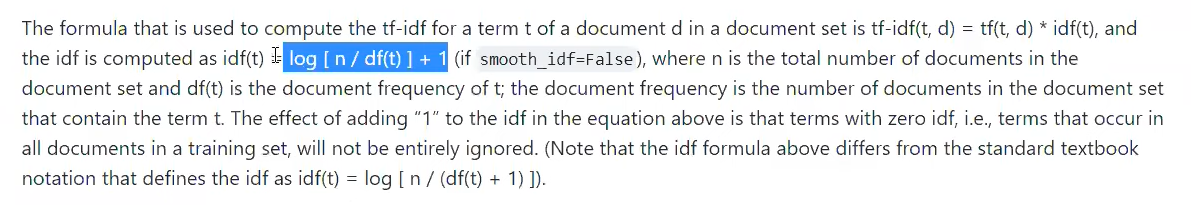